The objective of this notebook is to fine-tune the neural network architecture.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..')) 
import pandas as pd


import numpy as np
import torch
import matplotlib.pyplot as plt

from simulation.simulation import simulate_outer_market_paths, compute_fixing_window_size
from products.irs.gpu import calibrate_swap_rate_at_par
from cva_nn_estimator import compute_cva_labels
from nn_regressor import Regressor
from utils import train_with_oos_tracking
from utils import simulate_and_label


In [2]:
# keeping same params and setup as NMC 
# time discretization grid
dT = 0.1
num_substeps = 5
dt = dT / num_substeps
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)

# Vasicek short rate (a, b, sigma) / CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0.0
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015

# swaps ptf (same config as Nested Monte carlo IRS Case study)

np.random.seed(0)

num_irs = 100
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # heavy asset
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)


fixing_window_size = compute_fixing_window_size(irs, dt, dT)

# data
num_outer_train = 2**15   # 32 768 paths for train
num_outer_oos   = 2**13   # 8 192  paths as out-of-sample data

print(f"num_steps_total={num_steps_total}")
print(f"fixing_window_size={fixing_window_size}")
print(f"train paths={num_outer_train} | Out-of-sample paths = {num_outer_oos}")

num_steps_total=100
fixing_window_size=5
train paths=32768 | Out-of-sample paths = 8192


In the following we want to check whether the choice of architecture is robust over the life of the portfolio and repeat the experiment at $t \in \{1, 3, 5, 7\}$ years. 

In [ ]:
# in : in sample, oos : out-of-sample
features_in, labels_in = simulate_and_label(
    num_paths=32768, seed=42, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)

features_oos, labels_oos = simulate_and_label(
    num_paths=4096, seed=123, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)

pivots = [2.0, 3.0, 8.0] # selected pivot dates (early/ mid/ close to mat.)
n_units_list = [8, 16, 32, 64] 
n_layers_list = [2, 3]

logs = {}

# grid search
for t_year in pivots:
    t_idx = round(t_year / dT)
    for n_units in n_units_list:
        for n_layers in n_layers_list:
            in_log, oos_log = train_with_oos_tracking(
                X_tr=features_in[t_idx], y_tr=labels_in[t_idx],
                X_oos=features_oos[t_idx], y_oos=labels_oos[t_idx],
                hidden_units=n_units, num_hidden_layers=n_layers,
                num_epochs=128, batch_size=512, lr=1e-3,
                device='cuda', seed=0,
            )
            logs[(t_year, n_units, n_layers)] = (in_log, oos_log)
            print(f"t={t_year}y | h={n_units}×{n_layers} | "
                  f"final in-sample ={in_log[-1]:.4f} | final OOS={oos_log[-1]:.4f}")

/tmp/ipykernel_529482/3726817156.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


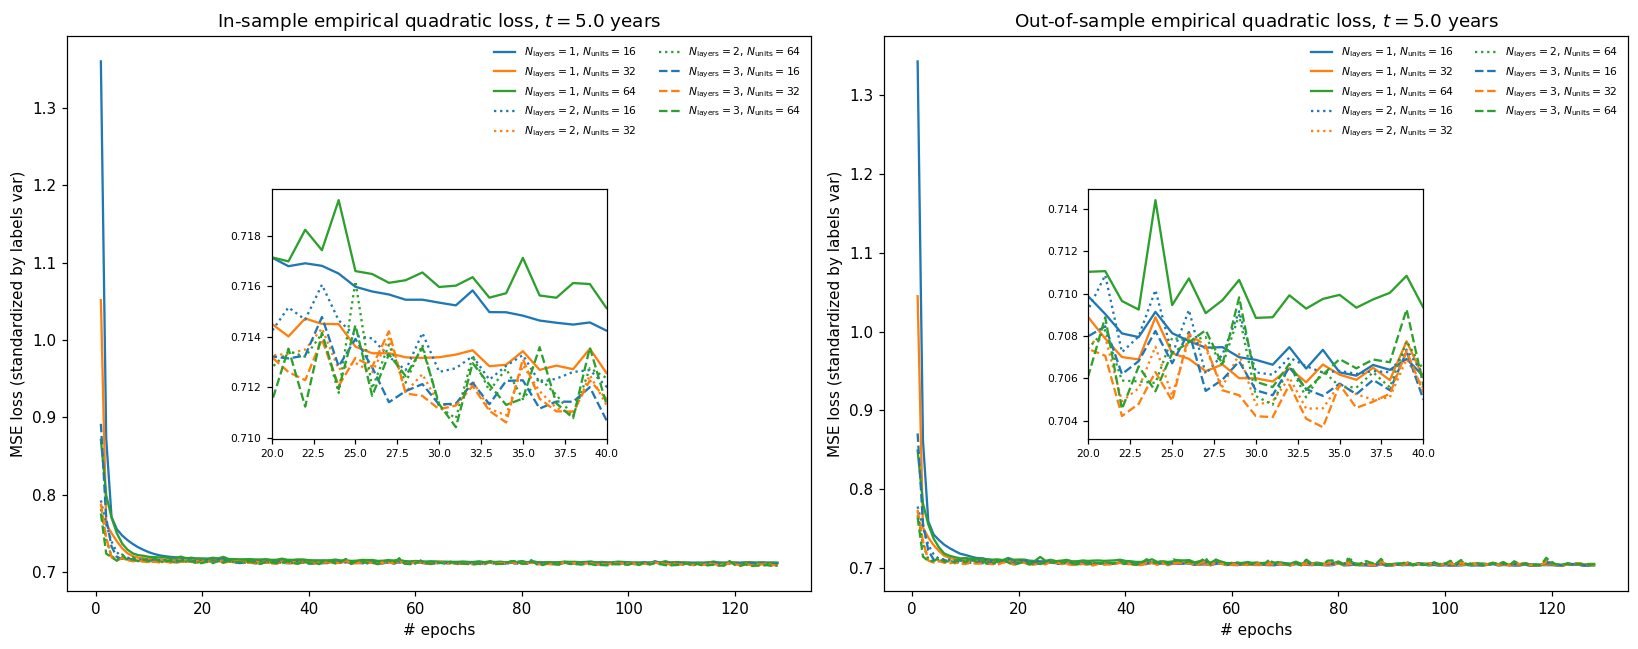